In [1]:
%reload_ext autoreload
%autoreload 2

# Score M5 Submissions

- **Naive Baseline** `data/naive_benchmark.snap.parquet`
- **Stats Baselines** `data/stat_benchmark.snap.parquet`
- **LightGbm** `data/ml_benchmark.snap.parquet`

In [2]:
import os
import time
from loguru import logger
from pathlib import Path
from tqdm import tqdm

import warnings

tqdm.pandas()
warnings.simplefilter(action='ignore', category=FutureWarning)
start_time = time.time()

# Read Data

In [3]:
from datasetsforecast.m5 import M5Evaluation
from src.process import *
from src.plots import *

HORIZON = 28
fcols = [f"F{i}" for i in range(1, HORIZON + 1)]

TRAIN_START = 1
TRAIN_END = 1941

TEST_START = 1942
TEST_END = 1969
TEST_DAYS = [f"d_{x}" for x in range(TEST_START, TEST_END + 1)]

truth = pd.read_csv(PATH_INPUT / "sales_test_evaluation.csv")
weights = pd.read_csv(PATH_INPUT / "weights_evaluation.csv")

wts = weights[weights["Level_id"] == "Level12"].copy()  # Level12 i.e. SKU-Location level
wts["item_id"] = pd.Categorical(wts["Agg_Level_1"])

## Load Actuals/Process Dates
dfin = pd.read_parquet("data/train.snap.parquet")
dfin["unique_id"] = dfin["item_id"].astype(str) + "_" + dfin["store_id"].astype(str)
d_date_mapper = dfin[["d", "date"]].drop_duplicates().set_index("d")["date"].to_dict()
fdays = [f"F{i + 1}" for i in range(HORIZON)]

test_start = dfin["date"].max() + pd.Timedelta(days=1)
test_days = pd.date_range(test_start, periods=HORIZON, freq="D")
f_date_mapper = dict(zip(fdays, test_days))

In [4]:
score_columns = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
dfids = get_dfids()

In [7]:
def score_submission(df: pd.DataFrame,
                     dfids: pd.DataFrame = None,
                     score_columns: List[str] = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
                    ) -> pd.DataFrame:
    """Score Submission
    """
    if dfids is None:
        dfids = get_dfids().set_index("id")

    try:
        df[score_columns]
    except KeyError:
        df = df.join(dfids)

    df_score = M5Evaluation.evaluate("data", df)
    return df_score

In [9]:
%%time

## Read Saved Submissions
naive_submission = pd.read_parquet("data/naive_benchmark.snap.parquet")
baseline_submission = pd.read_parquet("data/ml_baseline.snap.parquet")
ml_submission = pd.read_parquet("data/submission_mlforecast.snap.parquet")
lr_submission = pd.read_parquet("data/submission_linear_reg.snap.parquet")

naive_score = score_submission(naive_submission, dfids.set_index("id"), score_columns)
base_score = score_submission(baseline_submission, dfids.set_index("id"), score_columns)
ml_score = score_submission(ml_submission, dfids.set_index("id"), score_columns)
lr_score = score_submission(lr_submission, dfids.set_index("id"), score_columns)

CPU times: user 59.6 s, sys: 13.3 s, total: 1min 12s
Wall time: 1min 14s


In [33]:
# df_score = naive_score.join(base_score, lsuffix="_naive", rsuffix="_baseline")
# df_score = df_score.join(ml_score.rename(columns={"wrmsse": "wrmsse_ml"}))

# # # df_score = df_score.join(ml_score, rsuffix="_ml")
# # df_score = ml_score.join(naive_score, lsuffix="_lgb", rsuffix="_naive")
# # # df_score = df_score.join(winner_score.rename(columns={"wrmsse": "wrmsse_winner"}))
# # # df_score = df_score.join(runnerup_score.rename(columns={"wrmsse": "wrmsse_second"}))
# df_score = df_score.join(lr_score).rename(columns={"wrmsse": "wrmsse_lr"})
# df_score

In [23]:
df_score.mean().sort_values()

wrmsse_ml          0.687637
wrmsse_lr          0.775114
wrmsse_baseline    0.784758
wrmsse_naive       1.752010
dtype: float64

In [111]:
# ## Read Saved Submissions
# naive_submission = pd.read_parquet("data/naive_benchmark.snap.parquet")
# baseline_submission = pd.read_parquet("data/ml_baseline.snap.parquet")
# ml_submission = pd.read_parquet("data/submission_mlforecast.snap.parquet")

# # # stat_predictions = pd.read_parquet("data/stat_benchmark.snap.parquet")

# # stat_cols = ['1WeekMA', '2WeekMA', '4WeekMA', 'CrostonClassic', 'CrostonOptimized', 'CrostonSBA']
# stat_preds = pd.read_parquet("data/stat_baseline.snap.parquet")
# stat_preds["unique_id"] = stat_preds["id"].progress_apply(lambda x: x.replace("_evaluation", ""))


 4%|▎         | 30490/853720 [00:00<00:01, 564892.55it/s]

In [5]:
# id_columns = ['unique_id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
# preds_ets = pd.read_parquet("data/ets_predictions.snap.parquet")

In [6]:
# def make_submission(preds: pd.DataFrame,
#                     h: int) -> pd.DataFrame:
#     wide = preds.pivot_table(index='id',
#                              columns='date',
#                              observed=True)
#     # wide.columns = [f'F{i+1}' for i in range(h)]
#     wide.columns = [f'd_{TEST_START + i}' for i in range(h)]
#     wide.columns.name = None
#     wide.index.name = 'id'
#     return wide

# Evaluation

- Use `datasetsforecast.m5.M5Evaluation` class to score `wrmsse` across 12 grouped forecasts
- Compare **1st and 2nd place** againts a `Naive forecast` from this Notebook

In [39]:
from typing import List, Tuple, Union
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# Set Plot Parameters
plt.rcParams["figure.figsize"] = (24, 6)
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'figure.titlesize': 18})
plt.rcParams['font.family'] = "DeJavu Serif"
plt.rcParams['font.serif'] = "Cambria Math"


id_vars = ('unique_id' , 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id')


def wide_to_long(dfwide: pd.DataFrame,
                 id_vars: Union[Tuple, List],
                 value_name: str = "Prediction", # Name for the forecast
                 ) -> pd.DataFrame:
    """Transforms wide dataframe to long format using id_vars as index.
    
    id_vars = ('unique_id' , 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id')
    """
    # 
    dflong = dfwide.melt(id_vars=id_vars, value_vars=fcols, value_name=value_name, var_name="d")
    return dflong

def plot_avg_wrmsse(df_score: pd.DataFrame, save_path: Union[str, Path] = None):
    """Creates Barplot of Avg WRMSSE for each Model.
    """
    # Example: Compute the WRMSSE and style it
    styled_df = df_score.mean().to_frame().sort_values(0).rename(columns={0: "avg_wrmsse"}).style.bar()
    
    # Convert styled dataframe to a standard dataframe for plotting
    df_sorted = df_score.mean().to_frame().sort_values(0).rename(columns={0: "avg_wrmsse"})
    
    # Plot the dataframe as a bar chart
    fig, ax = plt.subplots(figsize=(8, 6))
    df_sorted["avg_wrmsse"].plot(kind="barh", ax=ax, color="skyblue")
    ax.set_xlabel("WRMSSE Score")
    ax.set_ylabel("Model")
    ax.set_title("Average WRMSSE Scores")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# plot_avg_wrmsse(df_score, save_path="plots/avg_wrmsse_by_model.png")

# Score Submissions

## Models:
1. Naive
2. ML Baseline
3. 1st Place
4. 2nd Place


In [28]:
%%time

# naive_score = M5Evaluation.evaluate("data", naive_submission)
# ml_score = M5Evaluation.evaluate("data", ml_submission)

# Download Winning & Second Place Solutions & Score
m5_winner_url = 'https://github.com/Nixtla/m5-forecasts/raw/main/forecasts/0001 YJ_STU.zip'
m5_second_place_url = 'https://github.com/Nixtla/m5-forecasts/raw/main/forecasts/0002 Matthias.zip'

winner_score = M5Evaluation.evaluate('data', m5_winner_url)
runnerup_score = M5Evaluation.evaluate('data', m5_second_place_url)

m5_winner_forecasts = M5Evaluation.load_benchmark('data', m5_winner_url)
m5_second_place_forecasts = M5Evaluation.load_benchmark('data', m5_second_place_url)

CPU times: user 32.5 s, sys: 14.1 s, total: 46.6 s
Wall time: 1min 17s


In [40]:
df_score = naive_score.join(base_score, lsuffix="_naive", rsuffix="_baseline")
df_score = df_score.join(ml_score.rename(columns={"wrmsse": "wrmsse_ml"}))
df_score = df_score.join(lr_score).rename(columns={"wrmsse": "wrmsse_lr"})
df_score = df_score.join(winner_score.rename(columns={"wrmsse": "wrmsse_winner"}))
df_score = df_score.join(runnerup_score.rename(columns={"wrmsse": "wrmsse_second"}))
df_score

,wrmsse_naive,wrmsse_baseline,wrmsse_ml,wrmsse_lr,wrmsse_winner,wrmsse_second
Total,1.752010,0.784758,0.687637,0.775114,0.520438,0.528165
Level1,1.966796,0.606760,0.414017,0.522048,0.198935,0.185895
Level2,1.904404,0.643303,0.493240,0.599686,0.309739,0.293886
Level3,1.879622,0.692046,0.563326,0.703741,0.399694,0.416379
Level4,1.946932,0.679122,0.503955,0.577883,0.276640,0.245872
Level5,1.913625,0.775778,0.646384,0.690135,0.365071,0.349167
Level6,1.880508,0.729554,0.598502,0.677562,0.389644,0.381001
Level7,1.878335,0.815996,0.715412,0.773639,0.474134,0.480634
Level8,1.798140,0.751714,0.648005,0.766767,0.479939,0.496947
Level9,1.764153,0.829412,0.755792,0.838091,0.572789,0.593662


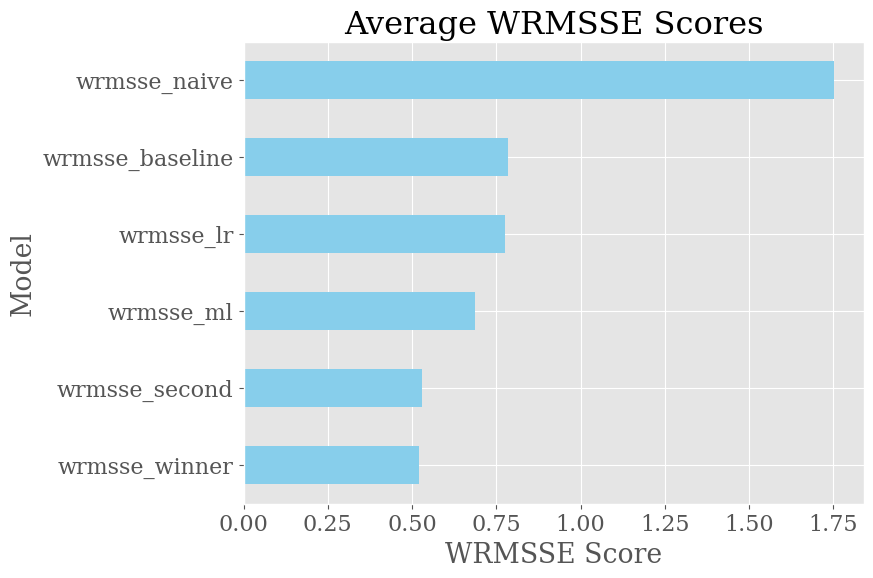

In [41]:
plot_avg_wrmsse(df_score)

In [7]:
# df_score = ml_score.join(naive_score, lsuffix="_lgb", rsuffix="_naive")
# df_score = df_score.join(winner_score.rename(columns={"wrmsse": "wrmsse_winner"}))
# df_score = df_score.join(runnerup_score.rename(columns={"wrmsse": "wrmsse_second"}))

In [8]:
df_score

,wrmsse_lgb,wrmsse_naive,wrmsse_winner,wrmsse_second
Total,0.784758,1.752010,0.520438,0.528165
Level1,0.606760,1.966796,0.198935,0.185895
Level2,0.643303,1.904404,0.309739,0.293886
Level3,0.692046,1.879622,0.399694,0.416379
Level4,0.679122,1.946932,0.276640,0.245872
Level5,0.775778,1.913625,0.365071,0.349167
Level6,0.729554,1.880508,0.389644,0.381001
Level7,0.815996,1.878335,0.474134,0.480634
Level8,0.751714,1.798140,0.479939,0.496947
Level9,0.829412,1.764153,0.572789,0.593662


In [42]:
df_score.mean().to_frame().sort_values(0).rename(columns={0: "avg_wrmsse"}).style.bar()

,avg_wrmsse
wrmsse_winner,0.520438
wrmsse_second,0.528165
wrmsse_ml,0.687637
wrmsse_lr,0.775114
wrmsse_baseline,0.784758
wrmsse_naive,1.752010


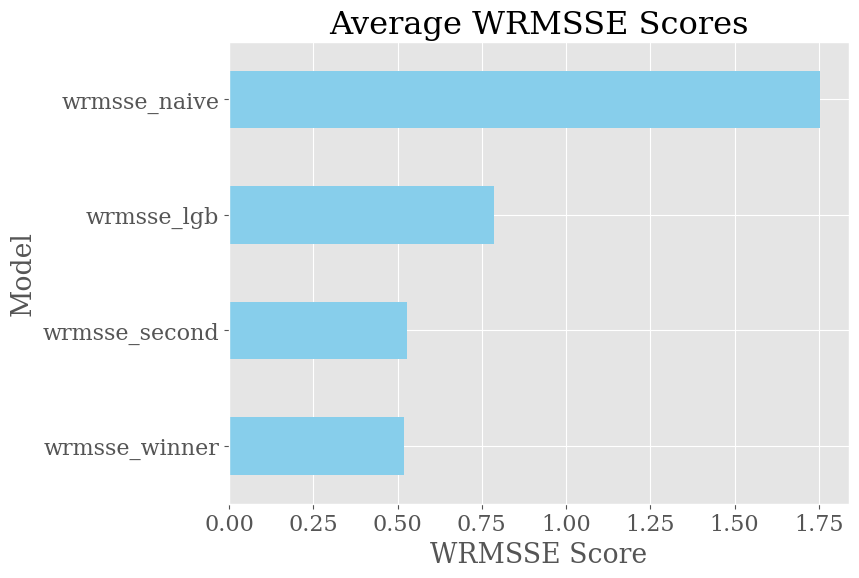

In [13]:
# Example: Compute the WRMSSE and style it
styled_df = df_score.mean().to_frame().sort_values(0).rename(columns={0: "avg_wrmsse"}).style.bar()

# Convert styled dataframe to a standard dataframe for plotting
df_sorted = df_score.mean().to_frame().sort_values(0).rename(columns={0: "avg_wrmsse"})

# Plot the dataframe as a bar chart
fig, ax = plt.subplots(figsize=(8, 6))
df_sorted["avg_wrmsse"].plot(kind="barh", ax=ax, color="skyblue")
ax.set_xlabel("WRMSSE Score")
ax.set_ylabel("Model")
ax.set_title("Average WRMSSE Scores")

plt.savefig("plots/avg_wrmsse_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

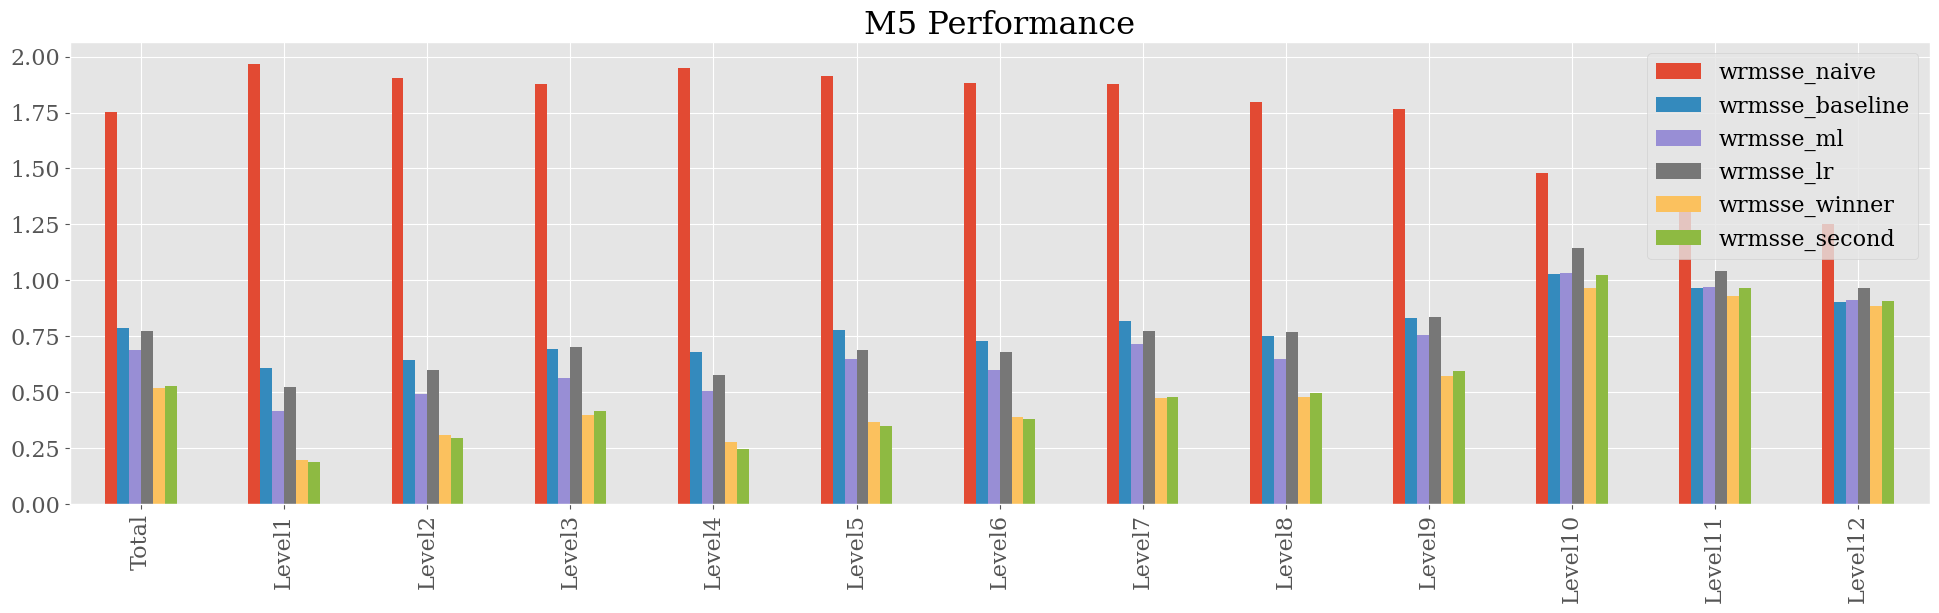

In [43]:
df_score.plot(kind="bar", title="M5 Performance")
plt.savefig("plots/Results.png")
plt.show()

# Create Single "Long" DataFrame for Model Comparison

In [125]:
winner_long = wide_to_long(m5_winner_forecasts, id_vars, "Winner")
runner_long = wide_to_long(m5_second_place_forecasts, id_vars, "Second")
# lgb_long = wide_to_long(ml_submission.rename(columns=dict(zip(TEST_DAYS, fcols)) | {"id": "unique_id"}), id_vars, "lgb")
# lgb_long["unique_id"] = lgb_long["unique_id"].str.replace("_evaluation", "")
# # naive_cols = ['unique_id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'] + fcols
naive_long = wide_to_long(naive_submission.rename(columns=dict(zip(TEST_DAYS, fcols))), id_vars, "Naive")

dflong = winner_long.merge(runner_long, on=list(id_vars) + ["d"])
# dflong =  dflong.merge(lgb_long, on=list(id_vars) + ["d"])
dflong = dflong.merge(naive_long[["unique_id", "d", "Naive"]], on=["unique_id", "d"])
# # dflong = dflong.merge(preds_ets[["unique_id", "date", "ETS"]], on=["unique_id", "date"])
long_ml = wide_to_long(ml_submission.reset_index().rename(columns={"id": "unique_id"}), ["unique_id"], "MLForecast")
long_ml["unique_id"] = long_ml["unique_id"].str.replace("_evaluation", "")
long_baseline = wide_to_long(baseline_submission.rename(columns=dict(zip(TEST_DAYS, fcols))), ["unique_id"], "Baseline") #.rename(columns={"id": "unique_id"})
long_baseline["unique_id"] = long_baseline["unique_id"].str.replace("_evaluation", "")
dflong = dflong.merge(long_ml, on=["unique_id", "d"])
dflong = dflong.merge(long_baseline, on=["unique_id", "d"])

lr_long = wide_to_long(lr_submission.reset_index(), ["id"], "LinearRegression")
lr_long["unique_id"] = lr_long["id"].str.replace("_evaluation", "")
dflong = dflong.merge(lr_long, on=["unique_id", "d"])

dflong["date"] = dflong["d"].map(f_date_mapper)
# # dflong = dflong.merge(preds_ets[["unique_id", "date", "ETS"]], on=["unique_id", "date"])
# dflong
dflong

,unique_id,item_id,dept_id,cat_id,store_id,state_id,d,Winner,Second,Naive,MLForecast,Baseline,id,LinearRegression,date
0,FOODS_1_001_CA_1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,F1,0.612648,0.626173,0.0,0.643767,0.727626,FOODS_1_001_CA_1_evaluation,0.614746,2016-05-23
1,FOODS_1_001_CA_2,FOODS_1_001,FOODS_1,FOODS,CA_2,CA,F1,0.859741,1.091531,0.0,0.820964,0.788495,FOODS_1_001_CA_2_evaluation,1.026033,2016-05-23
2,FOODS_1_001_CA_3,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,F1,0.611366,0.955920,2.0,0.843978,0.861809,FOODS_1_001_CA_3_evaluation,0.502498,2016-05-23
3,FOODS_1_001_CA_4,FOODS_1_001,FOODS_1,FOODS,CA_4,CA,F1,0.409594,0.374299,0.0,0.228239,0.249268,FOODS_1_001_CA_4_evaluation,0.480615,2016-05-23
4,FOODS_1_001_TX_1,FOODS_1_001,FOODS_1,FOODS,TX_1,TX,F1,0.559592,0.499221,2.0,0.542138,0.721801,FOODS_1_001_TX_1_evaluation,0.519952,2016-05-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853491,HOUSEHOLD_2_516_TX_2,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,TX_2,TX,F28,0.296055,0.187272,1.0,0.393280,0.399811,HOUSEHOLD_2_516_TX_2_evaluation,0.425716,2016-06-19
853492,HOUSEHOLD_2_516_TX_3,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,TX_3,TX,F28,0.200730,0.212107,2.0,0.332010,0.398666,HOUSEHOLD_2_516_TX_3_evaluation,0.222997,2016-06-19
853493,HOUSEHOLD_2_516_WI_1,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_1,WI,F28,0.189217,0.080137,0.0,0.260143,0.319998,HOUSEHOLD_2_516_WI_1_evaluation,0.058262,2016-06-19
853494,HOUSEHOLD_2_516_WI_2,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_2,WI,F28,0.034225,0.082279,0.0,0.238217,0.284496,HOUSEHOLD_2_516_WI_2_evaluation,0.059846,2016-06-19


# Visualize Results
1. Network
2. Item (top 5)
3. Item + Store (top 5)

## 1. Network Forecast

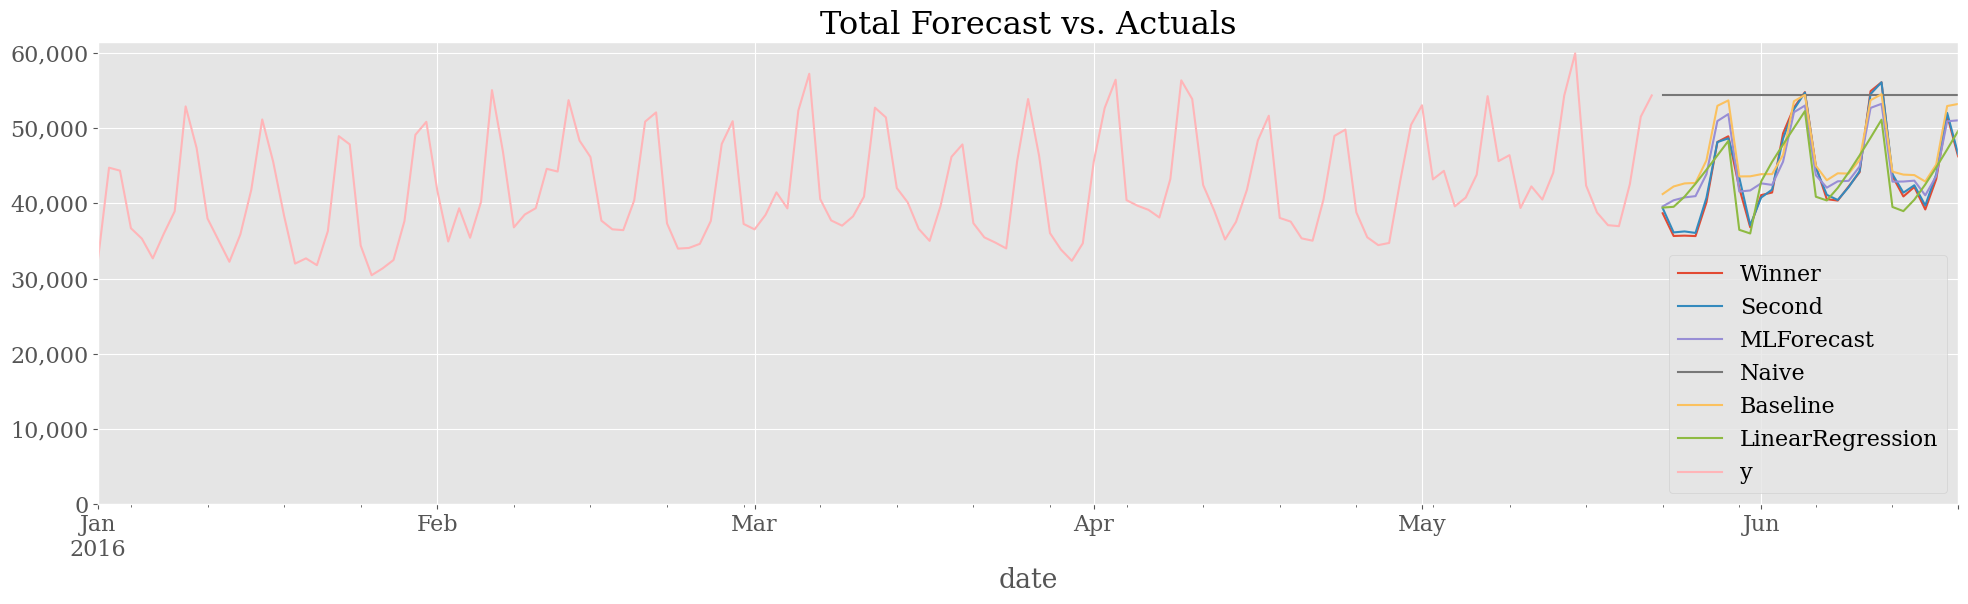

In [128]:
model_list = ["Winner", "Second", "lgb", "Naive"]
model_list = ["Winner", "Second", "MLForecast", "Naive", "Baseline", "LinearRegression",]

dfplot = dflong.groupby("date")[model_list].sum()
hist_total = dfin.groupby("date")[["y"]].sum()

plot_start = "2016-01-01"

fig, ax = plt.subplots()
dfplot.plot(ax=ax)

if plot_start is not None:
    hist_total = hist_total.loc[plot_start::]
hist_total.plot(ax=ax)
format_yaxis_thousands(ax)
ax.set_ylim(0)
ax.set_title(f"Total Forecast vs. Actuals")
plt.savefig("plots/TotalForecast.png")
plt.show()

## 2. Item Forecast

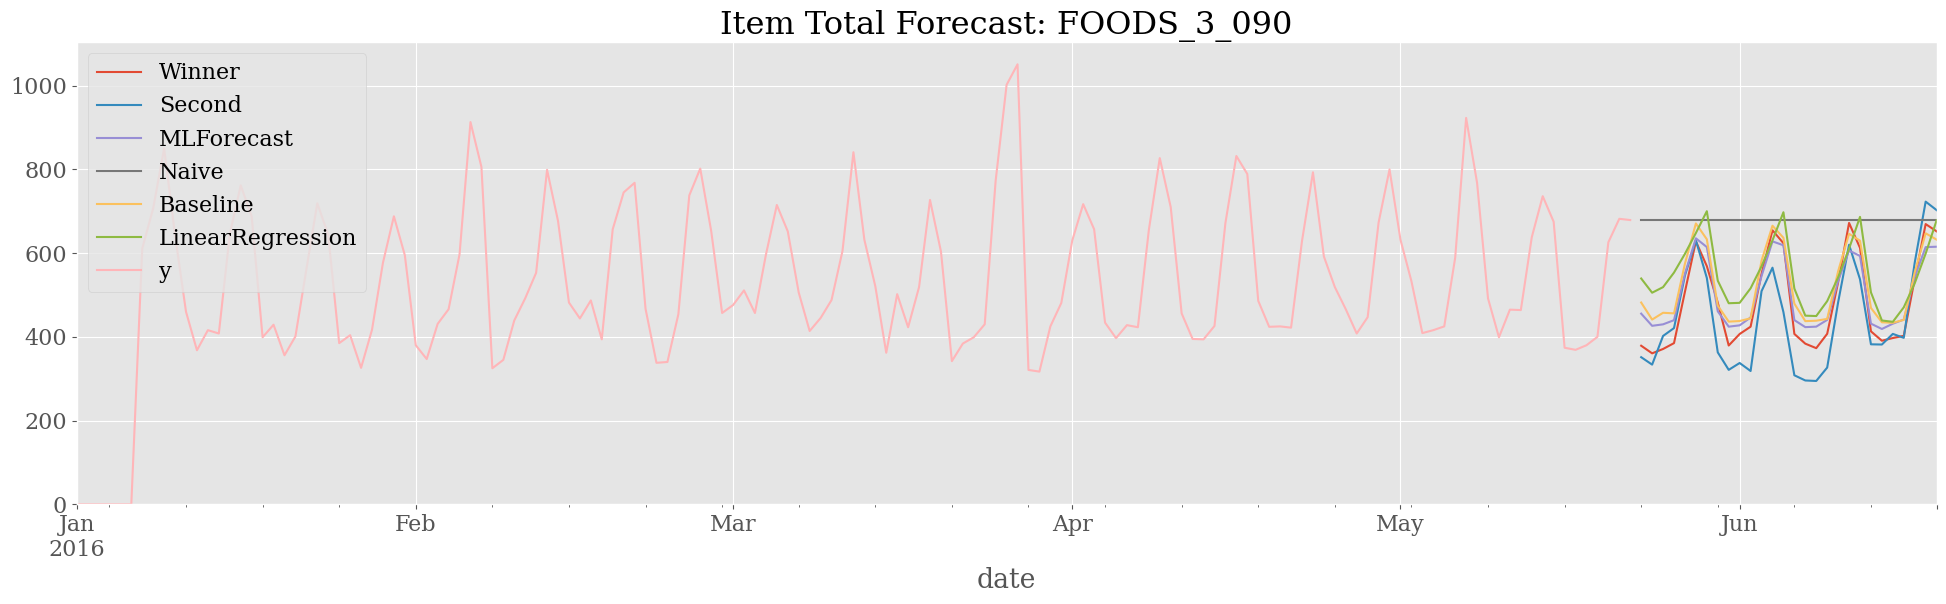

In [129]:
item_id = "FOODS_3_090"

def plot_item_forecast(item_id: str,
                       df_long_forecast: pd.DataFrame,
                       df_hist: pd.DataFrame = None,
                       save_path: Union[Path, str] = None,
                      ):
    """Plot Aggregate Item Demand (totaled across all stores) vs. Forecast.
    """
    dfplot = df_long_forecast[df_long_forecast["item_id"] == item_id].groupby(["date"])[model_list].sum()

    if df_hist is not None:
        item_hist = df_hist[df_hist["item_id"] == item_id].groupby("date")[["y"]].sum()
    
    if plot_start is not None:
        item_hist = item_hist.loc[plot_start::]
            
    fig, ax = plt.subplots()
    dfplot.plot(ax=ax)
    item_hist.plot(ax=ax)
    ax.set_ylim(0)
    ax.set_title(f"Item Total Forecast: {item_id}")

    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

plot_item_forecast(item_id, dflong, dfin, f"plots/Example_ItemForecast_{item_id}.png")

In [130]:
n_items = 100
top_items = dfin.groupby("item_id")["y"].sum().sort_values(ascending=False).head(n_items)
top_items = top_items.index.astype(str)

In [131]:
dflong

,unique_id,item_id,dept_id,cat_id,store_id,state_id,d,Winner,Second,Naive,MLForecast,Baseline,id,LinearRegression,date
0,FOODS_1_001_CA_1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,F1,0.612648,0.626173,0.0,0.643767,0.727626,FOODS_1_001_CA_1_evaluation,0.614746,2016-05-23
1,FOODS_1_001_CA_2,FOODS_1_001,FOODS_1,FOODS,CA_2,CA,F1,0.859741,1.091531,0.0,0.820964,0.788495,FOODS_1_001_CA_2_evaluation,1.026033,2016-05-23
2,FOODS_1_001_CA_3,FOODS_1_001,FOODS_1,FOODS,CA_3,CA,F1,0.611366,0.955920,2.0,0.843978,0.861809,FOODS_1_001_CA_3_evaluation,0.502498,2016-05-23
3,FOODS_1_001_CA_4,FOODS_1_001,FOODS_1,FOODS,CA_4,CA,F1,0.409594,0.374299,0.0,0.228239,0.249268,FOODS_1_001_CA_4_evaluation,0.480615,2016-05-23
4,FOODS_1_001_TX_1,FOODS_1_001,FOODS_1,FOODS,TX_1,TX,F1,0.559592,0.499221,2.0,0.542138,0.721801,FOODS_1_001_TX_1_evaluation,0.519952,2016-05-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853491,HOUSEHOLD_2_516_TX_2,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,TX_2,TX,F28,0.296055,0.187272,1.0,0.393280,0.399811,HOUSEHOLD_2_516_TX_2_evaluation,0.425716,2016-06-19
853492,HOUSEHOLD_2_516_TX_3,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,TX_3,TX,F28,0.200730,0.212107,2.0,0.332010,0.398666,HOUSEHOLD_2_516_TX_3_evaluation,0.222997,2016-06-19
853493,HOUSEHOLD_2_516_WI_1,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_1,WI,F28,0.189217,0.080137,0.0,0.260143,0.319998,HOUSEHOLD_2_516_WI_1_evaluation,0.058262,2016-06-19
853494,HOUSEHOLD_2_516_WI_2,HOUSEHOLD_2_516,HOUSEHOLD_2,HOUSEHOLD,WI_2,WI,F28,0.034225,0.082279,0.0,0.238217,0.284496,HOUSEHOLD_2_516_WI_2_evaluation,0.059846,2016-06-19


In [132]:
n_items = 5
top_items = dflong.groupby("item_id")["Naive"].sum().sort_values(ascending=False).head(n_items) #.values.astype(str)
display(top_items)

item_id
FOODS_3_090    19012.0
FOODS_3_586    16324.0
FOODS_3_252    11648.0
FOODS_3_120     9968.0
FOODS_3_681     8960.0
Name: Naive, dtype: float32

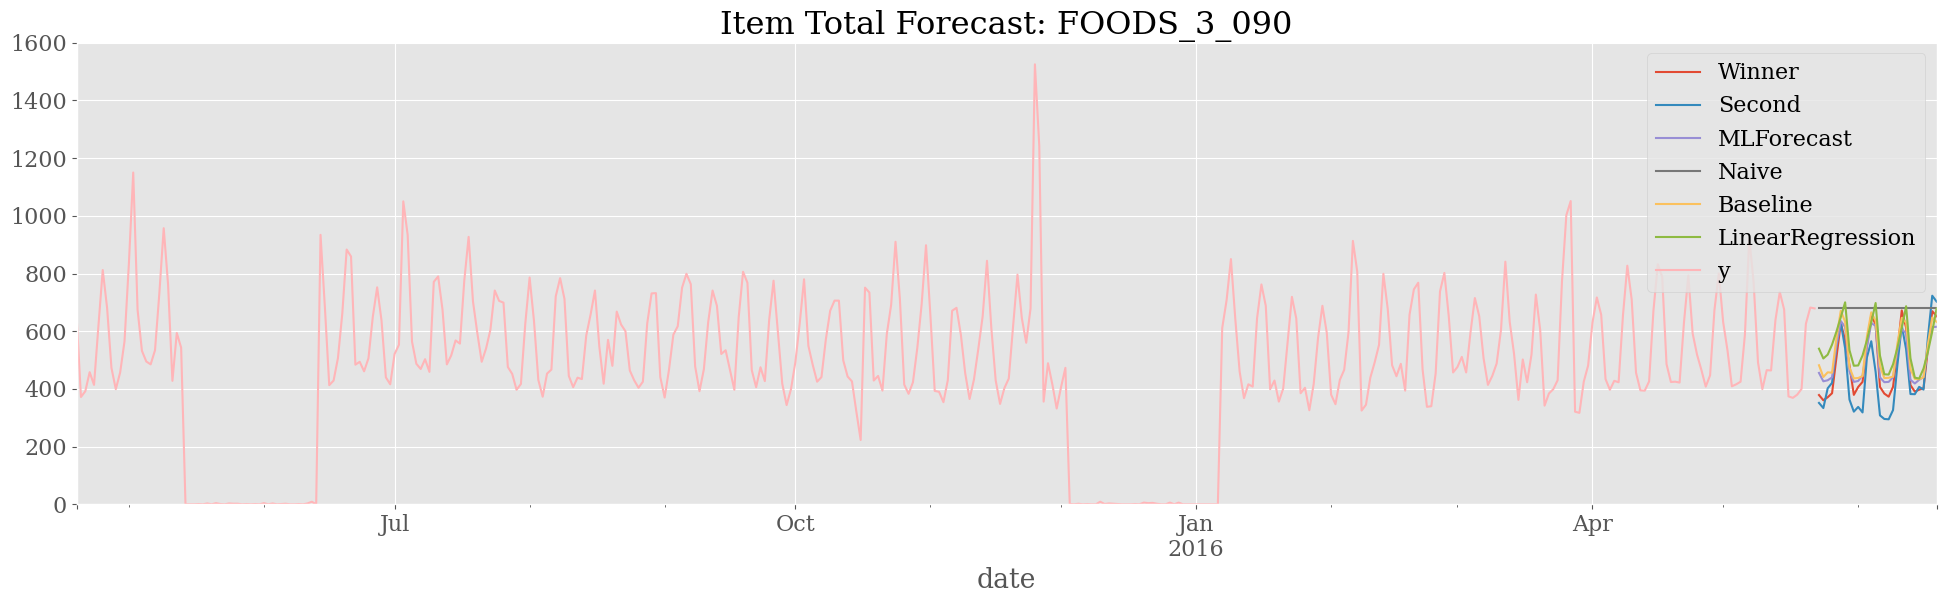

In [133]:
plot_start = "2015-01-01"
# item_id = "FOODS_1_001"

model_list = ["Winner", "Second", "lgb", "Naive"]
model_list = ["Winner", "Second", "MLForecast", "Naive", "Baseline", "LinearRegression",]

for item_id in top_items.index.tolist():
    plot_item_forecast(item_id, dflong, dfin)
    break

In [134]:
stat_preds = pd.read_parquet("data/stat_baseline.snap.parquet")
stat_preds["unique_id"] = stat_preds["id"].progress_apply(lambda x: x.replace("_evaluation", ""))


 4%|▎         | 30490/853720 [00:00<00:01, 581580.55it/s]

## Bottom Level Forecast (Item + Store)

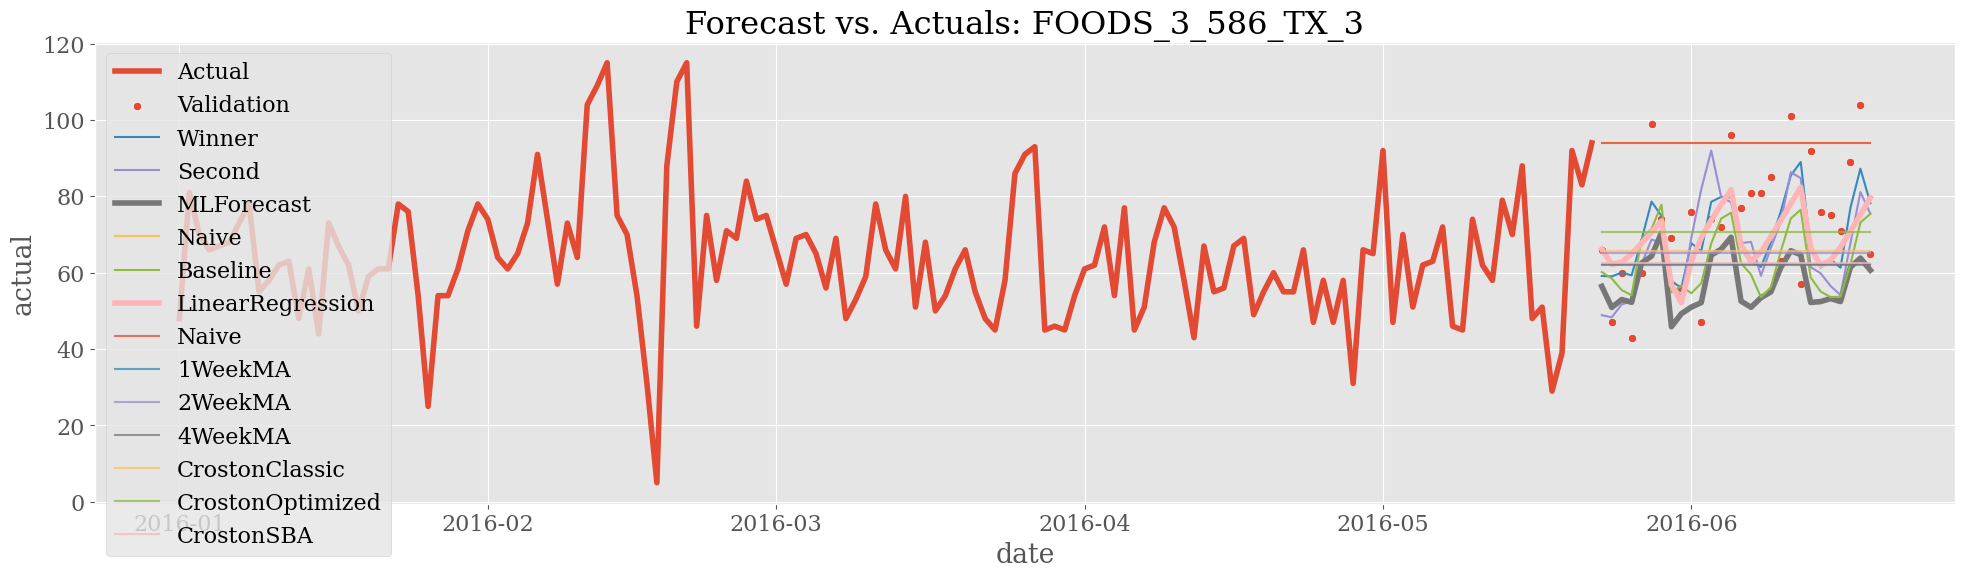

In [136]:
stat_cols = ['1WeekMA', '2WeekMA', '4WeekMA', 'CrostonClassic', 'CrostonOptimized', 'CrostonSBA']

top_n = 5   # grab the largest ids from the test set
truth["unique_id"] = truth["item_id"] + "_" + truth["store_id"]
top_ids = truth.set_index("unique_id")[TEST_DAYS].sum(axis=1).sort_values().index[-top_n:].tolist()
top_ids

plot_start = "2016-01-01"
# model_names = ['Winner', 'Second', 'Rick', 'Naive']
model_names = ["Winner", "Second", "lgb",]
model_names = ["Winner", "Second", "MLForecast", "Naive", "Baseline", "LinearRegression",]

stat_models_to_plot = ["CrostonOptimized"]

stat_models_to_plot = ['Naive', '1WeekMA', '2WeekMA', '4WeekMA', 'CrostonClassic', 'CrostonOptimized', 'CrostonSBA']

for _id in top_ids:
    df = dfin[dfin["unique_id"] == _id]
    hist = df.groupby("date")["y"].sum()
    dfs = stat_preds[stat_preds["unique_id"] == _id].reset_index(drop=True)
    dfs["d"] = fdays
    fcast = dflong[dflong["unique_id"] == _id]
    fcast = fcast.merge(dfs[["unique_id", "d", "date"] + stat_cols], on=["unique_id", "date"])
    val = truth[truth["unique_id"] == _id]
    fcast["actual"] = val[[d for d in val.columns if d.startswith("d_")]].values[0]
    
    f, ax = plt.subplots()
    
    if plot_start is not None:
        hist = hist.loc[plot_start::]
    
    sns.lineplot(x=hist.index, y=hist.values, label="Actual", ax=ax, linewidth=4)
    # sns.lineplot(x=fcast["date"], y=fcast["actual"], label="Validation", ax=ax, linewidth=3)
    sns.scatterplot(x=fcast["date"], y=fcast["actual"], label="Validation", ax=ax)
    
    for model in model_names:
        if model == "MLForecast":
            sns.lineplot(x=fcast["date"], y=fcast[model], ax=ax, label=model, linewidth=4)
        elif model == "LinearRegression":
            sns.lineplot(x=fcast["date"], y=fcast[model], ax=ax, label=model, linewidth=4)
        else:
            sns.lineplot(x=fcast["date"], y=fcast[model], ax=ax, label=model)

    for stat_model in stat_models_to_plot:
        sns.lineplot(x=fcast["date"], y=fcast[stat_model], ax=ax, label=stat_model, alpha=.75)
    
    ax.set_title(f"Forecast vs. Actuals: {_id}")
    # plt.savefig("plots/ExampleForecast.png")
    plt.show()
    break

In [108]:
print(f"""Notebook finished in {(time.time() - start_time) / 60:.2f}m""")

Notebook finished in 117.45m
